<a href="https://colab.research.google.com/github/RavinduThamodya/LSTM_Modeling/blob/main/Code_group%2002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas

In [ ]:
!pip install mplfinance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

In [ ]:
# Core Scientific Computing
import numpy as np
import pandas as pd
import random
import os

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

# Machine Learning Utilities
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Data Source
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import mplfinance as mpf

# Set Plotly as default backend for pandas
pd.options.plotting.backend = "plotly"

In [ ]:
#import visualkeras

# **Task 1: Preparing Data**

In [ ]:
tickers = ['DPZ', 'PZZA', 'MCD']
start_date = '2021-04-01'
end_date = '2026-03-31'

In [ ]:
all_stocks = []

for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.reset_index(inplace=True)

    df['Company'] = ticker
    all_stocks.append(df)

final_df = pd.concat(all_stocks, ignore_index=True)
final_df = final_df.sort_values(by=['Date', 'Company']).reset_index(drop=True)
final_df.to_csv('stocks.csv', index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
files.download('stocks.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_df.head(5)

Price,Date,Open,High,Low,Close,Volume,Company
0,2021-04-01,346.458222,352.760026,344.098571,349.623169,567600,DPZ
1,2021-04-01,200.541287,201.924825,199.300568,201.023300,2441200,MCD
2,2021-04-01,76.789022,77.970927,76.093782,76.893311,582900,PZZA
3,2021-04-05,349.267351,349.969631,343.920666,347.993896,701700,DPZ
4,2021-04-05,202.264056,204.852602,201.898085,204.272415,2866300,MCD


In [ ]:
final_df['Date'] = pd.to_datetime(final_df['Date'])

# **EDA & Data Preprocessing**

In [ ]:
# Example for DPZ
dpz_df = final_df[final_df['Company']=='DPZ'].copy()

In [ ]:
dpz_df.describe()

Price,Date,Open,High,Low,Close,Volume
count,1254,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,2023-09-28 08:24:06.889952,404.254923,409.095925,399.356067,404.177884,6.198811e+05
min,2021-04-01 00:00:00,278.772035,280.264685,273.499900,277.336792,1.849000e+05
25%,2022-06-29 06:00:00,366.079831,370.431600,362.659283,365.821297,4.307250e+05
50%,2023-09-27 12:00:00,405.945433,411.452231,401.518663,406.164948,5.423500e+05
75%,2024-12-25 12:00:00,448.030935,454.338305,442.464196,448.630753,7.127000e+05
max,2026-03-30 00:00:00,531.004187,534.478945,524.902008,531.427856,3.821500e+06
std,NaN,57.903416,58.346206,57.414273,57.921446,3.303730e+05


In [ ]:
mcd_df = final_df[final_df['Company'] == 'MCD']

In [ ]:
mcd_df.describe()

Price,Date,Open,High,Low,Close,Volume
count,1254,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,2023-09-28 08:24:06.889952,261.013023,262.943929,259.053151,261.059301,3.042048e+06
min,2021-04-01 00:00:00,200.541287,201.924825,198.634202,201.023300,1.011500e+06
25%,2022-06-29 06:00:00,233.116731,235.466579,231.669256,233.052319,2.283350e+06
50%,2023-09-27 12:00:00,261.063424,262.871377,258.328757,260.668823,2.782150e+06
75%,2024-12-25 12:00:00,287.567856,289.976252,285.280000,287.223206,3.406550e+06
max,2026-03-30 00:00:00,339.165348,339.851517,333.705852,339.165344,1.879200e+07
std,NaN,32.754482,33.009953,32.499761,32.783286,1.233351e+06


In [ ]:
pzza_df = final_df[final_df['Company'] == 'PZZA']

In [ ]:
pzza_df.describe()

Price,Date,Open,High,Low,Close,Volume
count,1254,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,2023-09-28 08:24:06.889952,65.461287,66.548840,64.349974,65.427840,8.313502e+05
min,2021-04-01 00:00:00,28.991500,29.707930,28.810005,29.087025,1.550000e+05
25%,2022-06-29 06:00:00,45.009709,46.005766,44.130847,45.010429,4.432500e+05
50%,2023-09-27 12:00:00,65.529151,66.653129,64.577280,65.613873,6.509000e+05
75%,2024-12-25 12:00:00,78.094969,79.669614,77.214452,78.259329,9.672250e+05
max,2026-03-30 00:00:00,121.118949,122.877295,117.852332,122.292084,1.226450e+07
std,NaN,22.874871,23.121789,22.651099,22.896122,8.162022e+05


In [ ]:
pivot_df = final_df.pivot(index='Date', columns='Company', values='Close')

/tmp/ipykernel_4923/2612087475.py:2: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



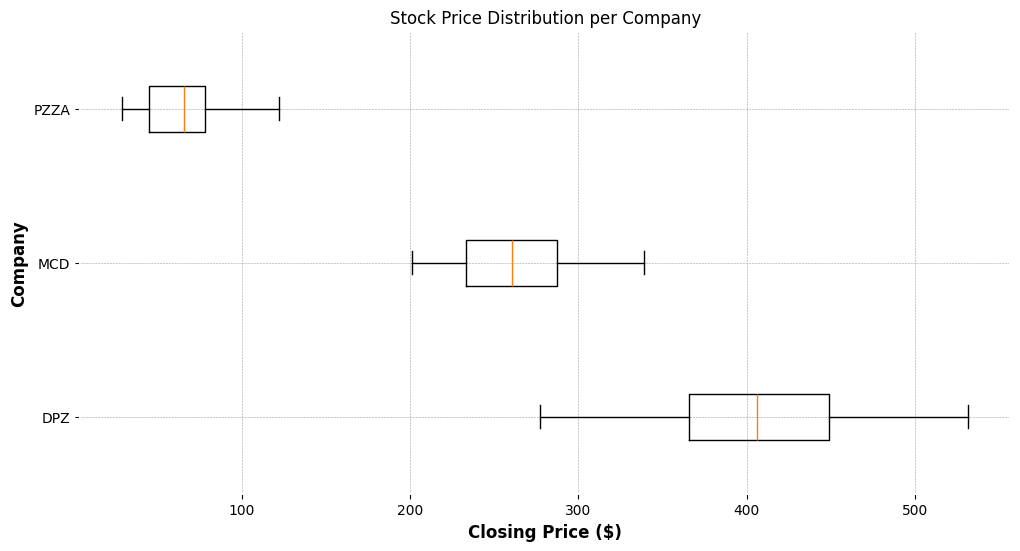

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot([pivot_df[col].dropna() for col in pivot_df.columns],
            labels=pivot_df.columns,
            vert=False)  # horizontal box plot
plt.title("Stock Price Distribution per Company")
plt.xlabel("Closing Price ($)")  # x-axis now shows price
plt.ylabel("Company")
plt.grid(True)
plt.show()

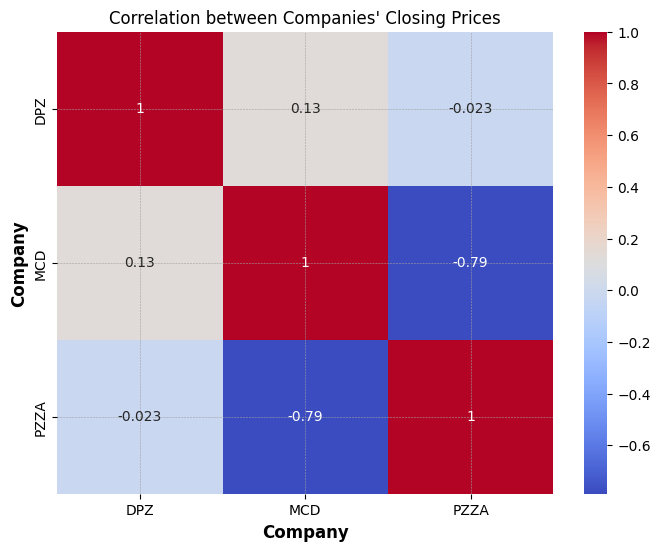

In [ ]:
corr_matrix = pivot_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation between Companies' Closing Prices")
plt.show()

 Identifies if scaling or outlier removal is needed before training. Wide price ranges across stocks confirm StandardScaler is necessary to normalize inputs

# **DPZ Modeling**

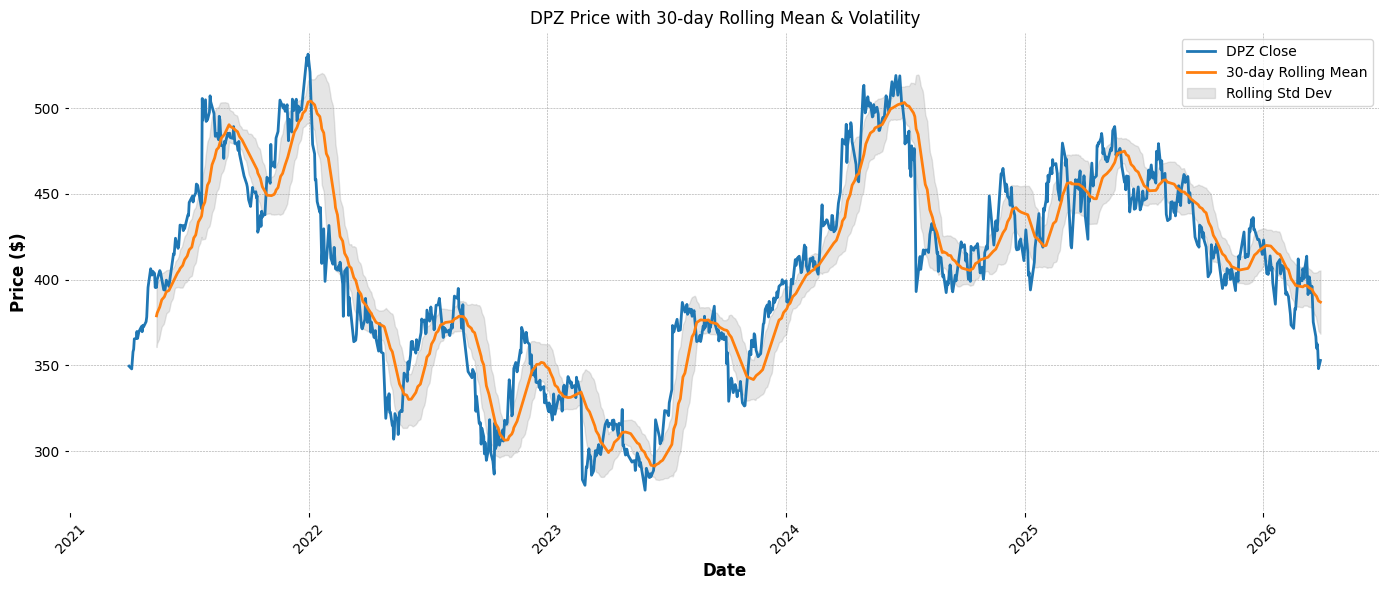

In [ ]:
# 30-day rolling mean and std (DPZ only)
rolling_mean = pivot_df['DPZ'].rolling(window=30).mean()
rolling_std = pivot_df['DPZ'].rolling(window=30).std()

plt.figure(figsize=(14,6))

# DPZ actual price
plt.plot(pivot_df['DPZ'], label='DPZ Close')

# rolling mean
plt.plot(rolling_mean, label='30-day Rolling Mean')

# volatility band
plt.fill_between(
    pivot_df.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='gray',
    alpha=0.2,
    label='Rolling Std Dev'
)

plt.title("DPZ Price with 30-day Rolling Mean & Volatility")
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




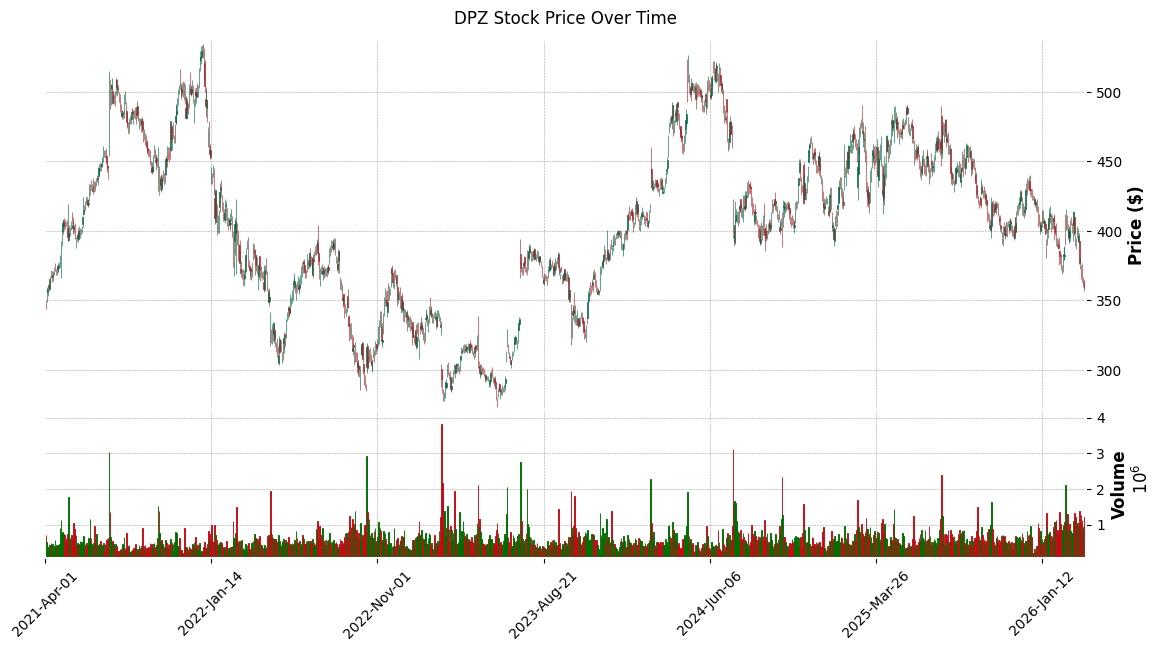

In [ ]:
# 1. Convert date
final_df['Date'] = pd.to_datetime(final_df['Date'])

# 2. Set index
df_plot = final_df.set_index('Date')

# 3. Filter ONLY DPZ
ticker = 'DPZ'
ticker_data = df_plot[df_plot['Company'] == ticker].copy()

# 4. Prepare OHLCV data
plot_data = ticker_data[['Open', 'High', 'Low', 'Close', 'Volume']]
plot_data = plot_data.sort_index().dropna()

# 5. Style
my_style = mpf.make_mpf_style(
    base_mpf_style='charles',
    gridstyle='--',
    facecolor='white'
)

# 6. Plot
fig, axlist = mpf.plot(
    plot_data,
    type='candle',
    style=my_style,
    volume=True,
    ylabel='Price ($)',
    ylabel_lower='Volume',
    figsize=(12, 6),
    returnfig=True,
    tight_layout=True
)

# 7. Title
axlist[0].set_title(
    f"{ticker} Stock Price Over Time",
    fontsize=12,
    pad=12
)

plt.show()

A candlestick chart with volume bars was used to visualize DPZ stock price movements over the five-year period. It shows daily Open, High, Low, and Close prices, helping identify trends, volatility, and price ranges more effectively than a line chart. Volume bars indicate the strength of price movements, while also helping detect support and resistance levels and sudden structural changes that may affect LSTM model performance.

### Train Test Data Preparation

In [ ]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

Since stock price data is a time series, the observations were first arranged in chronological order to preserve the temporal sequence. An 80:20 train-test split was then applied, where the first 80% of the data was used for training and the remaining 20% for testing. This approach ensures that past data is used to predict future values, maintaining the real-world forecasting structure and preventing data leakage.

The data is split before scaling to prevent data leakage. If scaling is done first, information from the test set influences the scaler, causing unrealistic model performance. By splitting first, the scaler is fitted only on training data and then applied to both training and testing sets, ensuring fair evaluation and realistic forecasting.

In [ ]:
#DATA PREPARATION
dpz_df_filtered = dpz_df[['Date', 'Close']]
dpz_df_filtered.set_index('Date', inplace=True)

dpz_df_filtered.index = pd.to_datetime(dpz_df_filtered.index)

dpz_df_filtered = dpz_df_filtered.sort_index()

dpz_train_size = int(len(dpz_df_filtered) * 0.8)

dpz_train_data = dpz_df_filtered[:dpz_train_size]
dpz_test_data = dpz_df_filtered[dpz_train_size:]

dpz_train_data_values = dpz_train_data.values
dpz_test_data_values = dpz_test_data.values

dpz_train_data_values

array([[349.62316895],
       [347.99389648],
       [356.4586792 ],
       ...,
       [459.06317139],
       [463.42922974],
       [439.67166138]])

Outlier removal was not applied because sudden price increases or decreases in stock data often represent real market behavior rather than errors. These fluctuations are important patterns influenced by events such as earnings reports, economic news, or market sentiment, and removing them could result in the loss of meaningful information needed for forecasting.

Scaling was necessary because LSTM models perform better when input values are on a similar numerical range. Stock prices can vary significantly in magnitude, and unscaled data may slow training and reduce model performance. By scaling the data, the model learns more efficiently, converges faster, and produces more stable predictions.

In [ ]:
#SCALING
dpz_scaler = StandardScaler()
dpz_scaled_train_data = dpz_scaler.fit_transform(dpz_train_data_values)
dpz_scaled_test_data = dpz_scaler.transform(dpz_test_data_values)

In [ ]:
# TRAIN DATA (SLIDING WINDOW)
# give sequence_dpz days as input to predict the next day's stock price
dpz_X_train, dpz_y_train = [], []
sequence_dpz = 90

for i in range(sequence_dpz, len(dpz_scaled_train_data)):
    dpz_X_train.append(dpz_scaled_train_data[i-sequence_dpz:i, 0])
    dpz_y_train.append(dpz_scaled_train_data[i, 0])

dpz_X_train, dpz_y_train = np.array(dpz_X_train), np.array(dpz_y_train)

dpz_X_train = np.reshape(dpz_X_train, (dpz_X_train.shape[0], dpz_X_train.shape[1], 1))

len(dpz_X_train[0])
dpz_y_train[0]

np.float64(1.4555266203281165)

In [ ]:
# TEST DATA
dpz_last_points = dpz_scaled_train_data[-sequence_dpz:]
dpz_combined_test_data = np.concatenate((dpz_last_points, dpz_scaled_test_data), axis=0)

dpz_X_test, dpz_y_test = [], dpz_test_data_values

for i in range(sequence_dpz, len(dpz_combined_test_data)):
    dpz_X_test.append(dpz_combined_test_data[i-sequence_dpz:i, 0])

dpz_X_test = np.array(dpz_X_test)
dpz_X_test = np.reshape(dpz_X_test, (dpz_X_test.shape[0], dpz_X_test.shape[1], 1))

### Model Development

LSTM was used because stock price data is sequential and depends on previous observations over time. Unlike traditional machine learning models, LSTM can learn long-term dependencies and temporal patterns in time series data, making it suitable for capturing trends, seasonality, and price movements. Its memory cell structure helps overcome the limitations of standard RNNs, such as the vanishing gradient problem, allowing better performance in stock price forecasting.

In [ ]:
# MODEL
dpz_model = keras.models.Sequential()

dpz_model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(dpz_X_train.shape[1], 1)))
dpz_model.add(keras.layers.LSTM(128, return_sequences=False))
dpz_model.add(keras.layers.Dense(128, activation="relu"))
dpz_model.add(keras.layers.Dropout(0.3))
dpz_model.add(keras.layers.Dense(1))

dpz_model.compile(optimizer="adam",
                  loss="mae",
                  metrics=['mse'])

dpz_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 90, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,353 (517.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dpz_first_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Training the Model

In [ ]:
dpz_training = dpz_model.fit(
    dpz_X_train,
    dpz_y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[dpz_first_callback],
    shuffle=False
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - loss: 0.4160 - mse: 0.3263 - val_loss: 0.2254 - val_mse: 0.0824
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - loss: 0.3499 - mse: 0.1909 - val_loss: 0.2212 - val_mse: 0.0856
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - loss: 0.3325 - mse: 0.1731 - val_loss: 0.2206 - val_mse: 0.0858
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - loss: 0.2207 - mse: 0.0888 - val_loss: 0.2115 - val_mse: 0.0821
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - loss: 0.1856 - mse: 0.0596 - val_loss: 0.2039 - val_mse: 0.0727
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - loss: 0.1906 - mse: 0.0649 - val_loss: 0.1900 - val_mse: 0.0607
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.1818 - mse: 0.0611 - val_loss: 0.1868 - val_mse: 0.0609
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step - loss: 0.1774 - mse: 0.0529 - val_loss: 0.1854 - val_mse: 0.0593
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - lo

In [ ]:
# graphical representation
pd.DataFrame(dpz_training.history).plot()

### Model Evaluation

In [ ]:
# Make a Prediction
dpz_predictions = dpz_model.predict(dpz_X_test)
dpz_predictions = dpz_scaler.inverse_transform(dpz_predictions)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step


In [ ]:
# Plotting data
dpz_test = dpz_test_data
dpz_test['dpz_predictions'] = dpz_predictions
dpz_test.plot()

/tmp/ipykernel_4923/1760518515.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# visualize the entire prediction
dpz_fig = go.Figure()

# train data
dpz_fig.add_trace(go.Scatter(x=dpz_train_data.index, y=dpz_train_data['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))

# test data
dpz_fig.add_trace(go.Scatter(x=dpz_test.index, y=dpz_test['Close'], mode='lines', name='Test (Actual)', line=dict(color='orange')))

# predicted data
dpz_fig.add_trace(go.Scatter(x=dpz_test.index, y=dpz_test['dpz_predictions'], mode='lines', name='Predictions', line=dict(color='red')))

# Update the layout
dpz_fig.update_layout(
    title="Our Stock Predictions DPZ",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

dpz_fig.show()

In [ ]:
# observe MAE
dpz_mae = mean_absolute_error(dpz_y_test, dpz_predictions)
print(f'Mean Absolute Error (MAE): {dpz_mae}')

Mean Absolute Error (MAE): 5.325133304671938


In [ ]:
# goodness of fit
dpz_r2 = r2_score(dpz_y_test, dpz_predictions)
print(f'R-squared (R²) Score: {dpz_r2}')

R-squared (R²) Score: 0.9477793919251926


### Model Predictions

In [ ]:
dpz_train_predict = dpz_model.predict(dpz_X_train)
dpz_test_predict = dpz_model.predict(dpz_X_test)

dpz_train_predict = dpz_scaler.inverse_transform(dpz_train_predict)
dpz_test_predict = dpz_scaler.inverse_transform(dpz_test_predict)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step


In [ ]:
# prepare the full prediction
dpz_full_predictions = pd.DataFrame(np.concatenate((dpz_train_predict, dpz_test_predict), axis=0))

# Get filtered data starting from index sequence_dpz
dpz_filtered_data_after_seq = dpz_df_filtered.iloc[sequence_dpz:].copy()
dpz_full_predictions.index = dpz_filtered_data_after_seq.index

# assign column names
dpz_full_predictions.columns = ['Predictions']

In [ ]:
# visualize the entire prediction
dpz_fig = go.Figure()

# full data
dpz_fig.add_trace(go.Scatter(x=dpz_df_filtered.index, y=dpz_df_filtered['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))

# predicted data
dpz_fig.add_trace(go.Scatter(x=dpz_full_predictions.index, y=dpz_full_predictions['Predictions'], mode='lines', name='Predictions', line=dict(color='red')))

# Update the layout
dpz_fig.update_layout(
    title="Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

dpz_fig.show()

### Future Forecast

In [ ]:
model_path_dpz = "/content/drive/MyDrive/stock_models/dpz_model.keras"
scaler_path_dpz = "/content/drive/MyDrive/stock_models/dpz_scaler.pkl"

model_dpz = load_model(model_path_dpz)

with open(scaler_path_dpz, "rb") as f:
    dpz_scaler_saved = pickle.load(f)

In [ ]:
df_dpz_fore = yf.download("DPZ", start="2025-04-01", end="2026-05-01")

/tmp/ipykernel_3310/3246128779.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Drop the Ticker level (level 1)
df_dpz_fore.columns = df_dpz_fore.columns.droplevel(1)

# (optional) ensure clean column names
df_dpz_fore.columns.name = None

# Final dataframe
df_dpz_final = df_dpz_fore[['Close', 'High', 'Low', 'Open', 'Volume']]

In [ ]:
df_dpz_final = df_dpz_final.reset_index()

df_dpz_filtered = df_dpz_final[['Date', 'Close']]

In [ ]:
df_dpz_filtered.set_index('Date', inplace=True)

In [ ]:
dpz_data_values = df_dpz_filtered.values
dpz_data_values

array([[451.79629517],
       [457.71600342],
       [460.54800415],
       [456.0541687 ],
       [436.81015015],
       [429.29742432],
       [423.54489136],
       [448.7479248 ],
       [445.50289917],
       [454.47103882],
       [467.94274902],
       [460.75454712],
       [454.54968262],
       [458.96484375],
       [460.46932983],
       [478.04171753],
       [477.78601074],
       [479.84115601],
       [479.45767212],
       [482.46673584],
       [485.21020508],
       [482.20120239],
       [473.37084961],
       [476.53713989],
       [469.87991333],
       [471.50247192],
       [468.73925781],
       [468.87692261],
       [470.92230225],
       [474.07876587],
       [476.33065796],
       [475.18014526],
       [477.81549072],
       [486.80322266],
       [489.23208618],
       [484.85620117],
       [472.48577881],
       [474.22631836],
       [472.42678833],
       [476.48800659],
       [475.06210327],
       [466.61523438],
       [465.9269104 ],
       [458

In [ ]:
dpz_scaled_forecast_data = dpz_scaler_saved.transform(dpz_data_values)

In [ ]:
# Take the last sequence_dpz days from the dataset for generating future predictions
dpz_last_days = dpz_scaled_forecast_data[-sequence_dpz:]

# Reshape
dpz_x_future = dpz_last_days.reshape((1, dpz_last_days.shape[0], 1))

In [ ]:
# to store predictions for the next 15 days
dpz_future_predictions = []

for _ in range(15):
    dpz_pred = model_dpz.predict(dpz_x_future)
    dpz_future_predictions.append(dpz_pred[0, 0])

    dpz_x_future = np.append(dpz_x_future[:, 1:, :], [[dpz_pred[0]]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


In [ ]:
# Convert back to the original scale
dpz_future_predictions = dpz_scaler.inverse_transform(np.array(dpz_future_predictions).reshape(-1, 1))
dpz_future_predictions

array([[342.2401 ],
       [345.67004],
       [349.80933],
       [354.13263],
       [358.36993],
       [362.3719 ],
       [366.059  ],
       [369.39578],
       [372.37012],
       [374.9682 ],
       [377.24146],
       [379.19217],
       [380.8526 ],
       [382.27567],
       [383.49164]], dtype=float32)

In [ ]:
# Store in a df
dpz_forecast_dates = pd.date_range(start=df_dpz_filtered.index[-1] + pd.Timedelta(days=1), periods=15, freq='B')
dpz_forecast = pd.DataFrame(dpz_future_predictions, index=dpz_forecast_dates, columns=['Prediction'])

dpz_forecast

,Prediction
2026-05-01,342.240112
2026-05-04,345.670044
2026-05-05,349.809326
2026-05-06,354.132629
2026-05-07,358.369934
2026-05-08,362.371887
2026-05-11,366.058990
2026-05-12,369.395782
2026-05-13,372.370117
2026-05-14,374.968201


In [ ]:
# visualize the prediction
dpz_fig = go.Figure()

# test data
dpz_fig.add_trace(go.Scatter(x=df_dpz_filtered.index, y=df_dpz_filtered['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))

# future data
dpz_fig.add_trace(go.Scatter(x=dpz_forecast.index, y=dpz_forecast['Prediction'], mode='lines', name='Predictions', line=dict(color='red')))

# Update the layout
dpz_fig.update_layout(
    title="DPZ Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

dpz_fig.show()

# **PZZA Modeling**

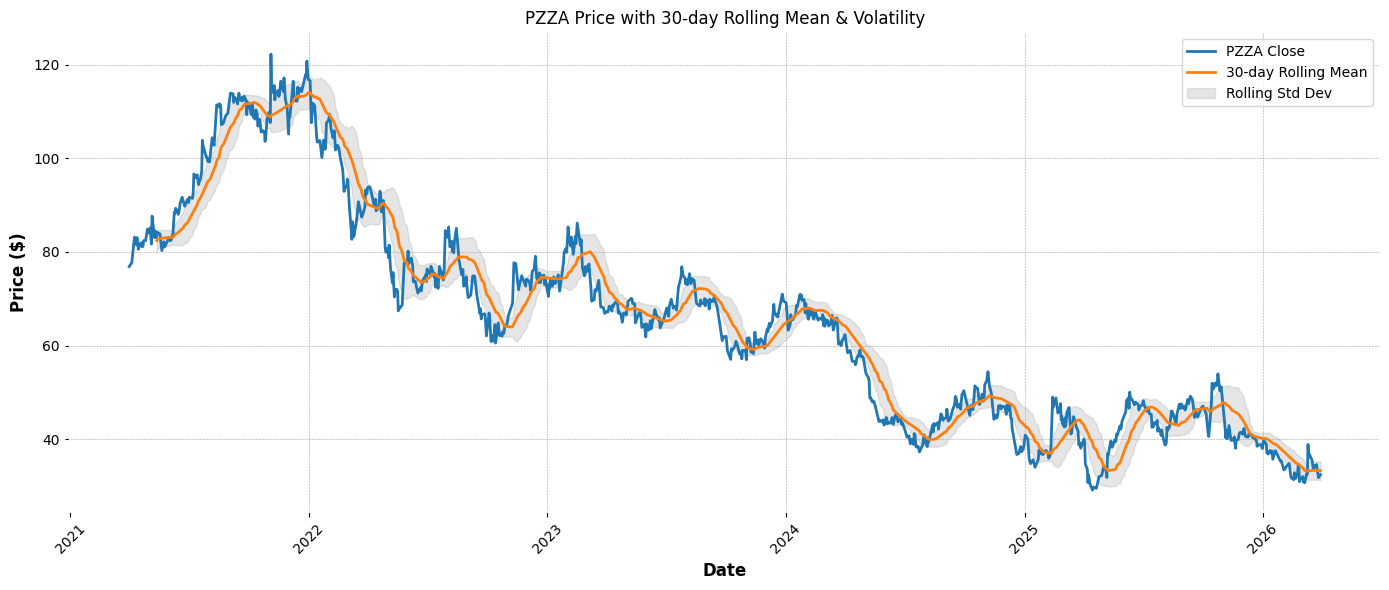

In [ ]:
# 30-day rolling mean and std
rolling_mean = pivot_df['PZZA'].rolling(window=30).mean()
rolling_std = pivot_df['PZZA'].rolling(window=30).std()

plt.figure(figsize=(14,6))

# PZZA actual price
plt.plot(pivot_df['PZZA'], label='PZZA Close')

# rolling mean
plt.plot(rolling_mean, label='30-day Rolling Mean')

# volatility band
plt.fill_between(
    pivot_df.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='gray',
    alpha=0.2,
    label='Rolling Std Dev'
)

plt.title("PZZA Price with 30-day Rolling Mean & Volatility")
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




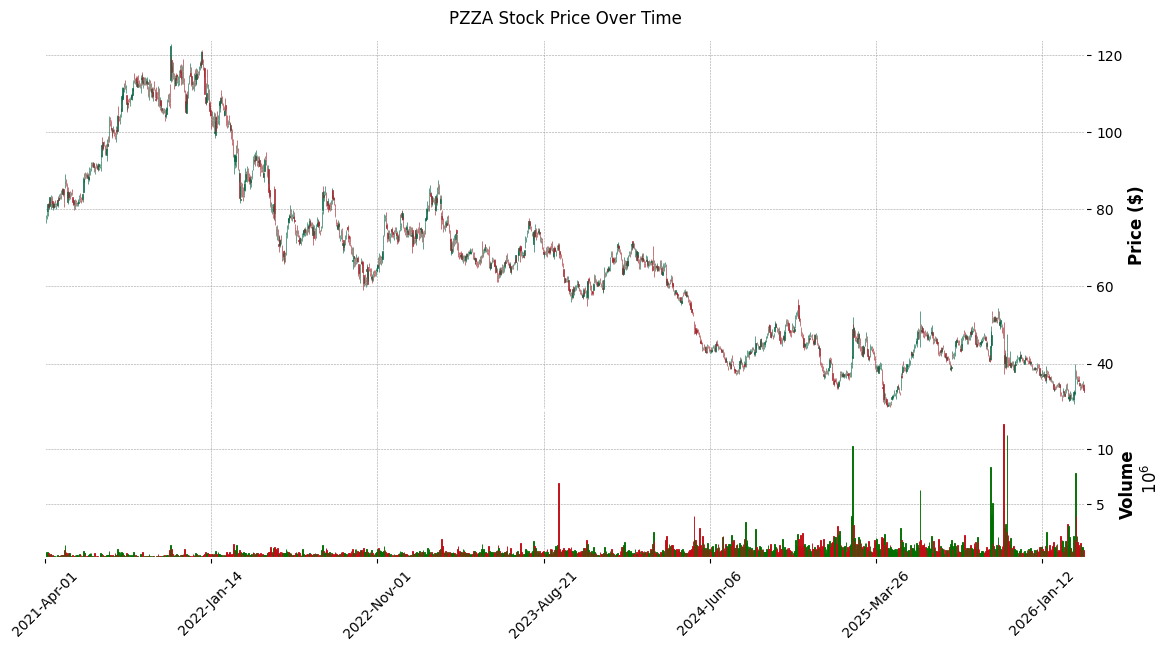

In [ ]:
# 1. Convert date
final_df['Date'] = pd.to_datetime(final_df['Date'])

# 2. Set index
df_plot = final_df.set_index('Date')

ticker = 'PZZA'
ticker_data = df_plot[df_plot['Company'] == ticker].copy()

# 4. Prepare OHLCV data
plot_data = ticker_data[['Open', 'High', 'Low', 'Close', 'Volume']]
plot_data = plot_data.sort_index().dropna()

# 5. Style
my_style = mpf.make_mpf_style(
    base_mpf_style='charles',
    gridstyle='--',
    facecolor='white'
)

# 6. Plot
fig, axlist = mpf.plot(
    plot_data,
    type='candle',
    style=my_style,
    volume=True,
    ylabel='Price ($)',
    ylabel_lower='Volume',
    figsize=(12, 6),
    returnfig=True,
    tight_layout=True
)

# 7. Title
axlist[0].set_title(
    f"{ticker} Stock Price Over Time",
    fontsize=12,
    pad=12
)

plt.show()

### Train Test Data Preparation

In [ ]:
seed = 42
np.random.seed(seed)

random.seed(seed)
tf.random.set_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

In [ ]:
# DATA PREPARATION
pzza_df_filtered = pzza_df[['Date', 'Close']]
pzza_df_filtered.set_index('Date', inplace=True)

pzza_df_filtered.index = pd.to_datetime(pzza_df_filtered.index)
pzza_df_filtered = pzza_df_filtered.sort_index()

pzza_train_size = int(len(pzza_df_filtered) * 0.8)

pzza_train_data = pzza_df_filtered[:pzza_train_size]
pzza_test_data = pzza_df_filtered[pzza_train_size:]

pzza_train_data_values = pzza_train_data.values
pzza_test_data_values = pzza_test_data.values

In [ ]:
# SCALING
pzza_scaler = StandardScaler()
pzza_scaled_train_data = pzza_scaler.fit_transform(pzza_train_data_values)
pzza_scaled_test_data = pzza_scaler.transform(pzza_test_data_values)


In [ ]:
# SEQUENCE
sequence_pzza = 90

In [ ]:
# TRAIN DATA
pzza_X_train, pzza_y_train = [], []

for i in range(sequence_pzza, len(pzza_scaled_train_data)):
    pzza_X_train.append(pzza_scaled_train_data[i-sequence_pzza:i, 0])
    pzza_y_train.append(pzza_scaled_train_data[i, 0])

pzza_X_train, pzza_y_train = np.array(pzza_X_train), np.array(pzza_y_train)

pzza_X_train = np.reshape(pzza_X_train, (pzza_X_train.shape[0], pzza_X_train.shape[1], 1))

In [ ]:
# TEST DATA
pzza_last_points = pzza_scaled_train_data[-sequence_pzza:]
pzza_combined_test_data = np.concatenate((pzza_last_points, pzza_scaled_test_data), axis=0)

pzza_X_test, pzza_y_test = [], pzza_test_data_values

for i in range(sequence_pzza, len(pzza_combined_test_data)):
    pzza_X_test.append(pzza_combined_test_data[i-sequence_pzza:i, 0])

pzza_X_test = np.array(pzza_X_test)
pzza_X_test = np.reshape(pzza_X_test, (pzza_X_test.shape[0], pzza_X_test.shape[1], 1))

### Model Development

In [ ]:
# MODEL
pzza_model = keras.models.Sequential()

pzza_model.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(pzza_X_train.shape[1], 1)))
pzza_model.add(keras.layers.LSTM(128, return_sequences=False))
pzza_model.add(keras.layers.Dense(128, activation="relu"))
pzza_model.add(keras.layers.Dropout(0.3))
pzza_model.add(keras.layers.Dense(1))

pzza_model.compile(optimizer="adam",
                   loss="mae",
                   metrics=['mse'])
pzza_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 90, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 477,953 (1.82 MB)

 Trainable params: 477,953 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pzza_first_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Training the Model

In [ ]:
# TRAINING
pzza_training = pzza_model.fit(
    pzza_X_train,
    pzza_y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[pzza_first_callback],
    shuffle=False
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 706ms/step - loss: 0.4069 - mse: 0.4398 - val_loss: 0.1216 - val_mse: 0.0231
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 539ms/step - loss: 0.3783 - mse: 0.3183 - val_loss: 0.2306 - val_mse: 0.0685
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 532ms/step - loss: 0.1888 - mse: 0.0609 - val_loss: 0.1298 - val_mse: 0.0261
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 576ms/step - loss: 0.2698 - mse: 0.1541 - val_loss: 0.2132 - val_mse: 0.0575
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 756ms/step - loss: 0.2279 - mse: 0.0951 - val_loss: 0.1238 - val_mse: 0.0235
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 541ms/step - loss: 0.1687 - mse: 0.0526 - val_loss: 0.0961 - val_mse: 0.0153
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 537ms/step - loss: 0.2550 - mse: 0.1165 - val_loss: 0.2609 - val_mse: 0.0787
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 537ms/step - loss: 0.1294 - mse: 0.0321 - val_loss: 0.0812 - val_mse: 0.0114
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 498ms/

In [ ]:
# PLOTTING
pd.DataFrame(pzza_training.history).plot()

### Model Evaluation

In [ ]:
# PREDICTION
pzza_predictions = pzza_model.predict(pzza_X_test)
pzza_predictions = pzza_scaler.inverse_transform(pzza_predictions)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step


In [ ]:
pzza_test = pzza_test_data
pzza_test['pzza_predictions'] = pzza_predictions
pzza_test.plot()

/tmp/ipykernel_3310/3955888935.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
pzza_fig = go.Figure()

pzza_fig.add_trace(go.Scatter(x=pzza_train_data.index, y=pzza_train_data['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))
pzza_fig.add_trace(go.Scatter(x=pzza_test.index, y=pzza_test['Close'], mode='lines', name='Test (Actual)', line=dict(color='orange')))
pzza_fig.add_trace(go.Scatter(x=pzza_test.index, y=pzza_test['pzza_predictions'], mode='lines', name='Predictions', line=dict(color='red')))

pzza_fig.update_layout(
    title="Stock Predictions PZZA",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

pzza_fig.show()

In [ ]:
# MAE
pzza_mae = mean_absolute_error(pzza_y_test, pzza_predictions)
print(f'MAE: {pzza_mae}')

MAE: 0.9783345104688668


In [ ]:
# R2
pzza_r2 = r2_score(pzza_y_test, pzza_predictions)
print(f'R²: {pzza_r2}')

R²: 0.9441585454404999


### Model Predictions

In [ ]:
pzza_train_predict = pzza_model.predict(pzza_X_train)
pzza_test_predict = pzza_model.predict(pzza_X_test)

pzza_train_predict = pzza_scaler.inverse_transform(pzza_train_predict)
pzza_test_predict = pzza_scaler.inverse_transform(pzza_test_predict)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


In [ ]:
pzza_full_predictions = pd.DataFrame(np.concatenate((pzza_train_predict, pzza_test_predict), axis=0))

pzza_filtered_data_after_seq = pzza_df_filtered.iloc[sequence_pzza:].copy()
pzza_full_predictions.index = pzza_filtered_data_after_seq.index

pzza_full_predictions.columns = ['Predictions']

In [ ]:
pzza_fig = go.Figure()

pzza_fig.add_trace(go.Scatter(x=pzza_df_filtered.index, y=pzza_df_filtered['Close'], mode='lines', name='Actual', line=dict(color='blue')))
pzza_fig.add_trace(go.Scatter(x=pzza_full_predictions.index, y=pzza_full_predictions['Predictions'], mode='lines', name='Predictions', line=dict(color='red')))

pzza_fig.update_layout(
    title="Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

pzza_fig.show()

### Future Forecast

In [ ]:
model_path_pzza = "/content/drive/MyDrive/stock_models/pzza_model.keras"
scaler_path_pzza = "/content/drive/MyDrive/stock_models/pzza_scaler.pkl"

model_pzza = load_model(model_path_pzza)

with open(scaler_path_pzza, "rb") as f:
    pzza_scaler_saved = pickle.load(f)

In [ ]:
df_pzza_fore = yf.download("PZZA", start="2025-03-31", end="2026-05-01")
#2025-03-31= the first date of train dataset

/tmp/ipykernel_3310/3432172003.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Drop the Ticker level (level 1)
df_pzza_fore.columns = df_pzza_fore.columns.droplevel(1)

# (optional) ensure clean column names
df_pzza_fore.columns.name = None

# Final dataframe
df_pzza_final = df_pzza_fore[['Close', 'High', 'Low', 'Open', 'Volume']]

In [ ]:
df_pzza_final = df_pzza_final.reset_index()

df_pzza_filtered = df_pzza_final[['Date', 'Close']]
df_pzza_filtered.set_index('Date', inplace=True)

In [ ]:
pzza_data_values = df_pzza_filtered.values
pzza_data_values

array([[39.24121857],
       [39.70928192],
       [39.99585342],
       [39.17434692],
       [34.70383453],
       [33.57665253],
       [30.70137787],
       [32.34439087],
       [30.99750519],
       [30.44346619],
       [29.62195969],
       [29.08702469],
       [29.65061569],
       [29.76524353],
       [29.49777794],
       [30.17599869],
       [31.27452278],
       [31.70438004],
       [31.98139954],
       [32.20110321],
       [32.21065903],
       [32.98439789],
       [33.05126953],
       [34.09247589],
       [33.8441124 ],
       [32.30617905],
       [31.80945587],
       [36.87221909],
       [36.55699539],
       [39.21256256],
       [39.59465408],
       [38.46747208],
       [38.2573204 ],
       [38.5343399 ],
       [39.87743759],
       [39.41363144],
       [39.61654663],
       [41.0949173 ],
       [40.82436752],
       [42.8148613 ],
       [42.11915207],
       [42.3413887 ],
       [43.72314072],
       [44.74737167],
       [44.82466888],
       [45

In [ ]:
pzza_scaled_forecast_data = pzza_scaler_saved.transform(pzza_data_values)

In [ ]:
# Take the last sequence_dpz days from the dataset for generating future predictions
pzza_last_days = pzza_scaled_forecast_data[-sequence_dpz:]

# Reshape
pzza_x_future = pzza_last_days.reshape((1, pzza_last_days.shape[0], 1))


In [ ]:
# to store predictions for the next 15 days
pzza_future_predictions = []

for _ in range(15):
    pzza_pred = model_pzza.predict(pzza_x_future)
    pzza_future_predictions.append(pzza_pred[0, 0])

    pzza_x_future = np.append(pzza_x_future[:, 1:, :], [[pzza_pred[0]]], axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [ ]:
# Convert back to the original scale
pzza_future_predictions = pzza_scaler.inverse_transform(np.array(pzza_future_predictions).reshape(-1, 1))
pzza_future_predictions


array([[35.544765],
       [35.45854 ],
       [35.348682],
       [35.241005],
       [35.13347 ],
       [35.024284],
       [34.912983],
       [34.79991 ],
       [34.685787],
       [34.571415],
       [34.4575  ],
       [34.344624],
       [34.23316 ],
       [34.123383],
       [34.015392]], dtype=float32)

In [ ]:
# Store in a df
pzza_forecast_dates = pd.date_range(start=df_pzza_filtered.index[-1] + pd.Timedelta(days=1), periods=15, freq='B')
pzza_forecast = pd.DataFrame(pzza_future_predictions, index=pzza_forecast_dates, columns=['Prediction'])

pzza_forecast

,Prediction
2026-05-01,35.544765
2026-05-04,35.458542
2026-05-05,35.348682
2026-05-06,35.241005
2026-05-07,35.133469
2026-05-08,35.024284
2026-05-11,34.912983
2026-05-12,34.799911
2026-05-13,34.685787
2026-05-14,34.571415


In [ ]:
# visualize the prediction
pzza_fig = go.Figure()

# test data
pzza_fig.add_trace(go.Scatter(x=df_pzza_filtered.index, y=df_pzza_filtered['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))

# future data
pzza_fig.add_trace(go.Scatter(x=pzza_forecast.index, y=pzza_forecast['Prediction'], mode='lines', name='Predictions', line=dict(color='red')))

# Update the layout
pzza_fig.update_layout(
    title="PZZA Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

pzza_fig.show()

# **MCD Modeling**

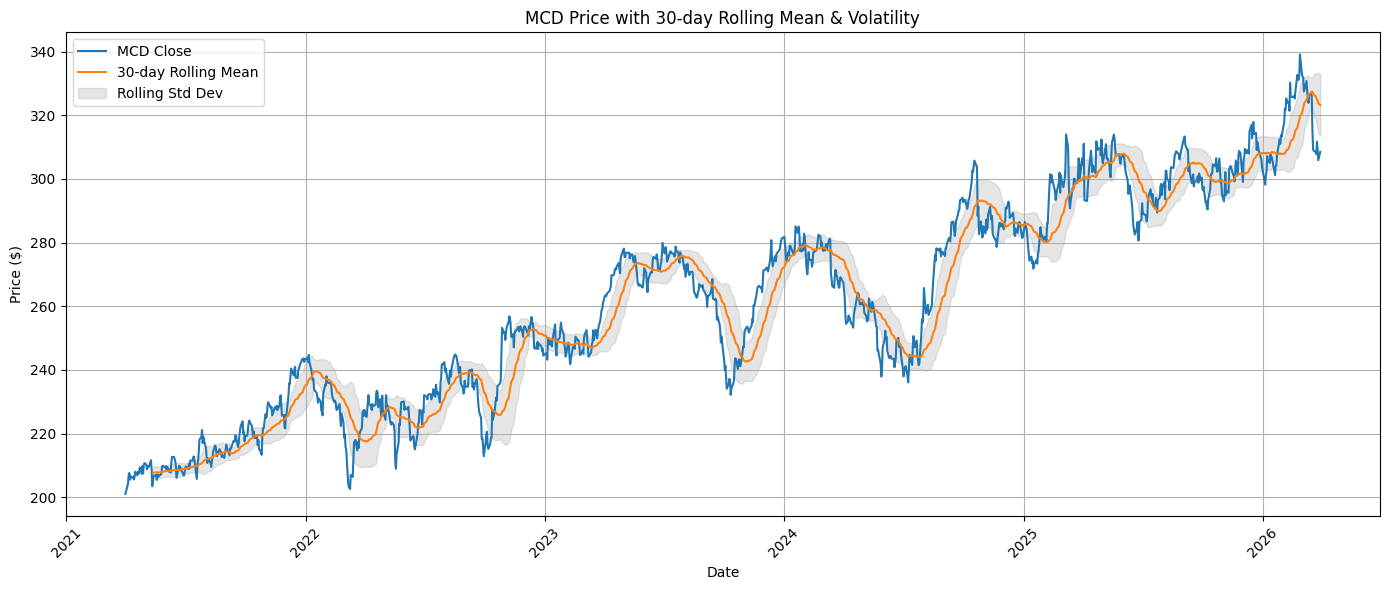

In [ ]:
# 30-day rolling mean and std
rolling_mean = pivot_df['MCD'].rolling(window=30).mean()
rolling_std = pivot_df['MCD'].rolling(window=30).std()

plt.figure(figsize=(14,6))

# MCD actual price
plt.plot(pivot_df['MCD'], label='MCD Close')

# rolling mean
plt.plot(rolling_mean, label='30-day Rolling Mean')

# volatility band
plt.fill_between(
    pivot_df.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='gray',
    alpha=0.2,
    label='Rolling Std Dev'
)

plt.title("MCD Price with 30-day Rolling Mean & Volatility")
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




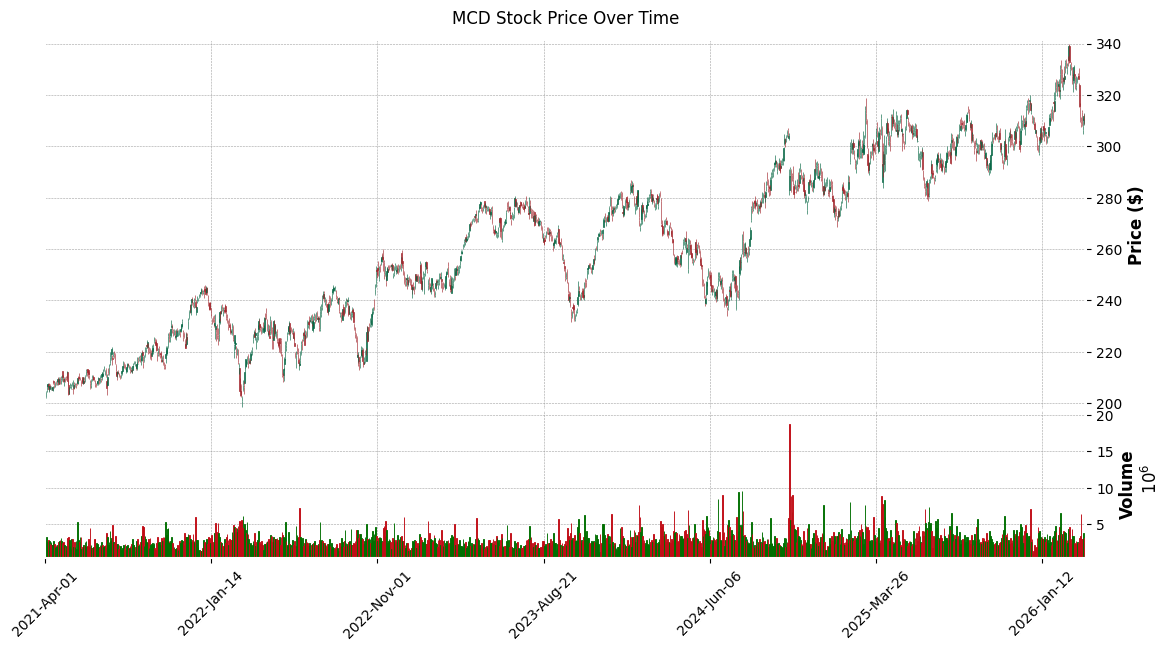

In [ ]:
# 1. Convert date
final_df['Date'] = pd.to_datetime(final_df['Date'])

# 2. Set index
df_plot = final_df.set_index('Date')

ticker = 'MCD'
ticker_data = df_plot[df_plot['Company'] == ticker].copy()

# 4. Prepare OHLCV data
plot_data = ticker_data[['Open', 'High', 'Low', 'Close', 'Volume']]
plot_data = plot_data.sort_index().dropna()

# 5. Style
my_style = mpf.make_mpf_style(
    base_mpf_style='charles',
    gridstyle='--',
    facecolor='white'
)

# 6. Plot
fig, axlist = mpf.plot(
    plot_data,
    type='candle',
    style=my_style,
    volume=True,
    ylabel='Price ($)',
    ylabel_lower='Volume',
    figsize=(12, 6),
    returnfig=True,
    tight_layout=True
)

# 7. Title
axlist[0].set_title(
    f"{ticker} Stock Price Over Time",
    fontsize=12,
    pad=12
)

plt.show()

### Train Test Data Preparation

In [ ]:
seed = 42
np.random.seed(seed)

random.seed(seed)
tf.random.set_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

In [ ]:
# DATA PREPARATION
mcd_df_filtered = mcd_df[['Date', 'Close']]
mcd_df_filtered.set_index('Date', inplace=True)

mcd_df_filtered.index = pd.to_datetime(mcd_df_filtered.index)
mcd_df_filtered = mcd_df_filtered.sort_index()

mcd_train_size = int(len(mcd_df_filtered) * 0.8)

mcd_train_data = mcd_df_filtered[:mcd_train_size]
mcd_test_data = mcd_df_filtered[mcd_train_size:]

mcd_train_data_values = mcd_train_data.values
mcd_test_data_values = mcd_test_data.values


In [ ]:
# SCALING
mcd_scaler = StandardScaler()
mcd_scaled_train_data = mcd_scaler.fit_transform(mcd_train_data_values)
mcd_scaled_test_data = mcd_scaler.transform(mcd_test_data_values)

In [ ]:
# SEQUENCE
sequence_mcd = 90

In [ ]:
# TRAIN DATA
mcd_X_train, mcd_y_train = [], []

for i in range(sequence_mcd, len(mcd_scaled_train_data)):
    mcd_X_train.append(mcd_scaled_train_data[i-sequence_mcd:i, 0])
    mcd_y_train.append(mcd_scaled_train_data[i, 0])

mcd_X_train, mcd_y_train = np.array(mcd_X_train), np.array(mcd_y_train)

mcd_X_train = np.reshape(mcd_X_train, (mcd_X_train.shape[0], mcd_X_train.shape[1], 1))

In [ ]:
# TEST DATA
mcd_last_points = mcd_scaled_train_data[-sequence_mcd:]
mcd_combined_test_data = np.concatenate((mcd_last_points, mcd_scaled_test_data), axis=0)

mcd_X_test, mcd_y_test = [], mcd_test_data_values

for i in range(sequence_mcd, len(mcd_combined_test_data)):
    mcd_X_test.append(mcd_combined_test_data[i-sequence_mcd:i, 0])

mcd_X_test = np.array(mcd_X_test)
mcd_X_test = np.reshape(mcd_X_test, (mcd_X_test.shape[0], mcd_X_test.shape[1], 1))

### Model Development

In [ ]:
mcd_model = keras.models.Sequential()

mcd_model.add(keras.layers.LSTM(128, return_sequences=True, input_shape=(mcd_X_train.shape[1], 1)))
mcd_model.add(keras.layers.LSTM(256, return_sequences=False))
mcd_model.add(keras.layers.Dense(512, activation="relu"))
mcd_model.add(keras.layers.Dropout(0.3))
mcd_model.add(keras.layers.Dense(1))

mcd_model.compile(optimizer="adam",
                  loss="mae",
                  metrics=['mse'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
mcd_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 90, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,897 (2.26 MB)

 Trainable params: 592,897 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mcd_first_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


### Training the Model

In [ ]:
mcd_training = mcd_model.fit(
    mcd_X_train,
    mcd_y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[mcd_first_callback],
    shuffle=False
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 543ms/step - loss: 0.3362 - mse: 0.2112 - val_loss: 0.8488 - val_mse: 0.8627
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 533ms/step - loss: 0.3280 - mse: 0.1661 - val_loss: 0.2742 - val_mse: 0.1182
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 540ms/step - loss: 0.2457 - mse: 0.1127 - val_loss: 0.6082 - val_mse: 0.4486
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - loss: 0.3207 - mse: 0.1482 - val_loss: 0.1615 - val_mse: 0.0442
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 563ms/step - loss: 0.1801 - mse: 0.0553 - val_loss: 0.1995 - val_mse: 0.0606
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 528ms/step - loss: 0.1496 - mse: 0.0365 - val_loss: 0.2460 - val_mse: 0.0879
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 493ms/step - loss: 0.1703 - mse: 0.0474 - val_loss: 0.2699 - val_mse: 0.1032
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 490ms/step - loss: 0.1557 - mse: 0.0384 - val_loss: 0.1590 - val_mse: 0.0401
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 536ms/

In [ ]:
pd.DataFrame(mcd_training.history).plot()

### Model Evaluation

In [ ]:
# PREDICTION
mcd_predictions = mcd_model.predict(mcd_X_test)
mcd_predictions = mcd_scaler.inverse_transform(mcd_predictions)

In [ ]:
mcd_test = mcd_test_data
mcd_test['mcd_predictions'] = mcd_predictions
mcd_test.plot()

In [ ]:
mcd_fig = go.Figure()

mcd_fig.add_trace(go.Scatter(x=mcd_train_data.index, y=mcd_train_data['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))
mcd_fig.add_trace(go.Scatter(x=mcd_test.index, y=mcd_test['Close'], mode='lines', name='Test (Actual)', line=dict(color='orange')))
mcd_fig.add_trace(go.Scatter(x=mcd_test.index, y=mcd_test['mcd_predictions'], mode='lines', name='Predictions', line=dict(color='red')))

mcd_fig.update_layout(
    title="Stock Predictions MCD",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

mcd_fig.show()

In [ ]:
#mae
mcd_mae = mean_absolute_error(mcd_y_test, mcd_predictions)
print(f'MAE: {mcd_mae}')

In [ ]:
#R2
mcd_r2 = r2_score(mcd_y_test, mcd_predictions)
print(f'R²: {mcd_r2}')

### Model Predictions

In [ ]:
# FULL PREDICTION
mcd_train_predict = mcd_model.predict(mcd_X_train)
mcd_test_predict = mcd_model.predict(mcd_X_test)
mcd_train_predict = mcd_scaler.inverse_transform(mcd_train_predict)
mcd_test_predict = mcd_scaler.inverse_transform(mcd_test_predict)

In [ ]:
mcd_full_predictions = pd.DataFrame(np.concatenate((mcd_train_predict, mcd_test_predict), axis=0))

mcd_filtered_data_after_seq = mcd_df_filtered.iloc[sequence_mcd:].copy()
mcd_full_predictions.index = mcd_filtered_data_after_seq.index

mcd_full_predictions.columns = ['Predictions']

In [ ]:
mcd_fig = go.Figure()

mcd_fig.add_trace(go.Scatter(x=mcd_df_filtered.index, y=mcd_df_filtered['Close'], mode='lines', name='Actual', line=dict(color='blue')))
mcd_fig.add_trace(go.Scatter(x=mcd_full_predictions.index, y=mcd_full_predictions['Predictions'], mode='lines', name='Predictions', line=dict(color='red')))

mcd_fig.update_layout(
    title="Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

mcd_fig.show()

### Future Forecast

In [ ]:
model_path_mcd = "/content/drive/MyDrive/stock_models/mcd_model.keras"
scaler_path_mcd = "/content/drive/MyDrive/stock_models/mcd_scaler.pkl"

model_mcd = load_model(model_path_mcd)

with open(scaler_path_mcd, "rb") as f:
    mcd_scaler_saved = pickle.load(f)

In [ ]:
df_mcd_fore = yf.download("MCD", start="2025-03-31", end="2026-05-01")
#2025-03-31= the first date of train dataset

/tmp/ipykernel_3310/2022883329.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Drop the Ticker level (level 1)
df_mcd_fore.columns = df_mcd_fore.columns.droplevel(1)

# (optional) ensure clean column names
df_mcd_fore.columns.name = None

# Final dataframe
df_mcd_final = df_mcd_fore[['Close', 'High', 'Low', 'Open', 'Volume']]


In [ ]:
df_mcd_final = df_mcd_final.reset_index()

df_mcd_filtered = df_mcd_final[['Date', 'Close']]
df_mcd_filtered.set_index('Date', inplace=True)


In [ ]:
mcd_data_values = df_mcd_filtered.values
mcd_data_values

array([[305.30706787],
       [306.53857422],
       [304.53491211],
       [311.07366943],
       [293.32424927],
       [293.10925293],
       [293.05059814],
       [297.08721924],
       [299.84344482],
       [302.8928833 ],
       [308.9234314 ],
       [305.41461182],
       [302.11102295],
       [304.26126099],
       [301.73959351],
       [311.86532593],
       [311.27890015],
       [309.07003784],
       [309.57824707],
       [309.64666748],
       [307.3888855 ],
       [312.42245483],
       [306.54833984],
       [304.90631104],
       [308.58132935],
       [309.62716675],
       [310.93682861],
       [306.40170288],
       [306.58743286],
       [304.86727905],
       [301.71026611],
       [300.54718018],
       [307.36935425],
       [311.40594482],
       [313.96673584],
       [312.56903076],
       [309.28500366],
       [307.20318604],
       [307.45733643],
       [307.82873535],
       [305.76641846],
       [304.80859375],
       [306.75363159],
       [307

In [ ]:
mcd_scaled_forecast_data = mcd_scaler_saved.transform(mcd_data_values)

In [ ]:
# Take the last sequence_dpz days from the dataset for generating future predictions
mcd_last_days = mcd_scaled_forecast_data[-sequence_dpz:]

# Reshape
mcd_x_future = mcd_last_days.reshape((1, mcd_last_days.shape[0], 1))

In [ ]:
# to store predictions for the next 15 days
mcd_future_predictions = []

for _ in range(15):
    mcd_pred = model_mcd.predict(mcd_x_future)
    mcd_future_predictions.append(mcd_pred[0, 0])

    mcd_x_future = np.append(mcd_x_future[:, 1:, :], [[mcd_pred[0]]], axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


In [ ]:
# Convert back to the original scale
mcd_future_predictions = mcd_scaler.inverse_transform(np.array(mcd_future_predictions).reshape(-1, 1))
mcd_future_predictions


array([[292.05176],
       [292.35287],
       [292.60123],
       [292.8028 ],
       [292.94458],
       [293.02606],
       [293.05655],
       [293.05072],
       [293.0241 ],
       [292.99057],
       [292.96033],
       [292.93954],
       [292.93073],
       [292.93292],
       [292.94345]], dtype=float32)

In [ ]:
# Store in a df
mcd_forecast_dates = pd.date_range(start=df_mcd_filtered.index[-1] + pd.Timedelta(days=1), periods=15, freq='B')
mcd_forecast = pd.DataFrame(mcd_future_predictions, index=mcd_forecast_dates, columns=['Prediction'])

mcd_forecast

,Prediction
2026-05-01,292.051758
2026-05-04,292.352875
2026-05-05,292.601227
2026-05-06,292.802795
2026-05-07,292.944580
2026-05-08,293.026062
2026-05-11,293.056549
2026-05-12,293.050720
2026-05-13,293.024109
2026-05-14,292.990570


In [ ]:
# visualize the prediction
mcd_fig = go.Figure()

# test data
mcd_fig.add_trace(go.Scatter(x=df_mcd_filtered.index, y=df_mcd_filtered['Close'], mode='lines', name='Train (Actual)', line=dict(color='blue')))

# future data
mcd_fig.add_trace(go.Scatter(x=mcd_forecast.index, y=mcd_forecast['Prediction'], mode='lines', name='Predictions', line=dict(color='red')))

# Update the layout
mcd_fig.update_layout(
    title="MCD Stock Predictions",
    xaxis_title="Date",
    yaxis_title="Close Price"
)

mcd_fig.show()

# **Save models**

In [ ]:
import os
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
save_dir = "/content/drive/MyDrive/stock_models"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
dpz_model_path = os.path.join(save_dir, "dpz_model.keras")
pzza_model_path = os.path.join(save_dir, "pzza_model.keras")
mcd_model_path = os.path.join(save_dir, "mcd_model.keras")

dpz_scaler_path = os.path.join(save_dir, "dpz_scaler.pkl")
pzza_scaler_path = os.path.join(save_dir, "pzza_scaler.pkl")
mcd_scaler_path = os.path.join(save_dir, "mcd_scaler.pkl")

In [ ]:
# SAVE MODELS
dpz_model.save(dpz_model_path)
pzza_model.save(pzza_model_path)
mcd_model.save(mcd_model_path)

In [ ]:
# SAVE SCALERS (IMPORTANT)
with open(dpz_scaler_path, "wb") as f:
    pickle.dump(dpz_scaler, f)

with open(pzza_scaler_path, "wb") as f:
    pickle.dump(pzza_scaler, f)

with open(mcd_scaler_path, "wb") as f:
    pickle.dump(mcd_scaler, f)